# Predicting Freight Cost

## Objective
Predict freight cost for a vendor invoice using **quantity** and **dollars**, to improve cost forecasting, budgeting, and vendor negotiation.

---

## Why this matters

- Freight is a **non-trivial component** of landed cost  
- Poor freight estimates distort **margin** and **inventory planning**  
- Automating freight estimation helps procurement teams **forecast true cost before invoice arrival**

In [3]:
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
conn = sqlite3.connect("../data/inventory.db")
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type = 'table'", conn)

In [5]:
tables

,name
0,begin_inventory
1,end_inventory
2,purchases
3,purchase_prices
4,vendor_invoice


In [6]:
for table in tables['name']:
    print('Table name:', table)
    df=pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn)
    display(df)

Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [7]:
vendor_df = pd.read_sql_query("SELECT * FROM vendor_invoice", conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [8]:
vendor_df[['Quantity','Freight','Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


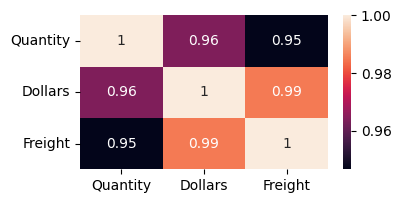

In [9]:
plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity','Dollars','Freight']].corr(),annot=True)
plt.show()
#Freight cost is more strongly correlated with total dollars than quantity, indicating value-based shipping costs.

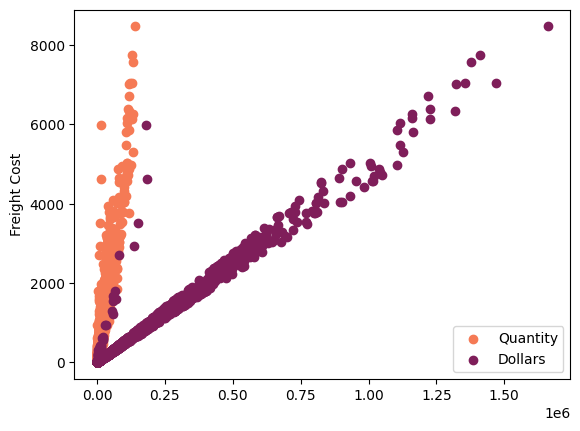

In [10]:
plt.scatter(vendor_df['Quantity'],vendor_df['Freight'],color='#f57a55')
plt.scatter(vendor_df['Dollars'],vendor_df['Freight'],color='#7f1e5a')
plt.legend(['Quantity','Dollars'])
plt.ylabel('Freight Cost')
plt.show()

In [11]:
vendor_df['freight_per_unit'] = vendor_df['Freight'] / vendor_df['Quantity']
vendor_df['freight_per_dollar'] = vendor_df['Freight'] / vendor_df['Dollars']
vendor_df['unit_cost'] = vendor_df['Dollars'] / vendor_df['Quantity']
vendor_df['is_bulk'] = (vendor_df['Quantity'] > vendor_df['Quantity'].median()).astype(int)

In [12]:
low_quantity =vendor_df['Quantity'].quantile(0.25)
high_quantity =vendor_df['Quantity'].quantile(0.75)

In [13]:
vendor_df.loc[vendor_df['Quantity']<low_quantity]['freight_per_unit'].mean()

np.float64(0.09489854253138316)

In [14]:
vendor_df.loc[vendor_df['Quantity']>high_quantity]['freight_per_unit'].mean()

np.float64(0.049077654690759046)

In [15]:
X = vendor_df[['Dollars', 'Quantity', 'unit_cost', 'is_bulk']]
y = vendor_df['Freight']

In [16]:
vendor_df.describe().round() 

,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_per_unit,freight_per_dollar,unit_cost,is_bulk
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0,0.0,12.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0,0.0,8.0,1.0
min,2.0,8106.0,1.0,4.0,0.0,0.0,0.0,1.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0,0.0,8.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0,0.0,10.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0,0.0,15.0,1.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0,0.0,184.0,1.0


In [17]:
from sklearn.model_selection import train_test_split, GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
model1 = LinearRegression()
model1.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
param_grid = {
    'max_depth': [3, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', None]
}

dt = DecisionTreeRegressor(random_state=42)

grid = GridSearchCV(dt, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

model2 = grid.best_estimator_

In [21]:
grid.best_params_

{'max_depth': 5,
 'max_features': None,
 'min_samples_leaf': 5,
 'min_samples_split': 2}

In [22]:
param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', None]
}
  
rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

model3 = grid.best_estimator_

In [23]:
grid.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 500}

In [24]:
def evaluate_model(model, X_test, y_test, model_name):
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)*100

    print(f"\n{model_name} Performance:")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2 score : {r2:.2f}%")

In [25]:
evaluate_model(model1, X_test, y_test, "Linear Regression")
evaluate_model(model2, X_test, y_test, "Decision Tree Regression")
evaluate_model(model3, X_test, y_test, "Random Forest Regression")
#Even after hyperparameter tuning, Linear Regression outperformed tree-based models, indicating that freight cost is primarily driven by a linear relationship with invoice value.


Linear Regression Performance:
MAE : 23.53
RMSE : 124.33
R2 score : 97.01%

Decision Tree Regression Performance:
MAE : 32.93
RMSE : 137.52
R2 score : 96.34%

Random Forest Regression Performance:
MAE : 26.33
RMSE : 131.87
R2 score : 96.63%


In [26]:
importances = model3.feature_importances_
for col, val in zip(X.columns, importances):
    print(f"{col}: {val:.3f}")
#Dollars is the strongest predictor, followed by quantity with unit cost and bulk being almost insignificant.

Dollars: 0.596
Quantity: 0.348
unit_cost: 0.027
is_bulk: 0.029


In [27]:
X_simple = vendor_df[['Dollars', 'Quantity']]
X_simple_train, X_simple_test, y_train, y_test = train_test_split(X_simple,y,test_size=0.2,random_state=42)
X_full = vendor_df[['Dollars', 'Quantity', 'unit_cost', 'freight_per_unit', 'is_bulk']]
model_simple = LinearRegression().fit(X_simple_train, y_train)
model_full = LinearRegression().fit(X_train, y_train)

In [31]:
pred_simple = model_simple.predict(X_simple_test)
pred_full = model_full.predict(X_test)   
r2_simple = r2_score(y_test, pred_simple)*100
r2_full = r2_score(y_test, pred_full)*100
mae_simple = mean_absolute_error(y_test, pred_simple)
mae_full = mean_absolute_error(y_test, pred_full)
print(f"\nMAE Comparison:")
print(f"Simple Model MAE: {mae_simple:.2f}")
print(f"Full Model MAE: {mae_full:.2f}")
print(f"Simple Model (Dollars only) R²: {r2_simple:.2f}%")
print(f"Full Model (All features) R²: {r2_full:.2f}%")



MAE Comparison:
Simple Model MAE: 24.46
Full Model MAE: 23.53
Simple Model (Dollars only) R²: 97.00%
Full Model (All features) R²: 97.01%


In [32]:
print("Key Insight:")
print("The negligible improvement (0.01%) confirms that freight cost is primarily driven by invoice value.")
print("This indicates a simple and predictable pricing structure where complex models are unnecessary.")

Key Insight:
The negligible improvement (0.01%) confirms that freight cost is primarily driven by invoice value.
This indicates a simple and predictable pricing structure where complex models are unnecessary.


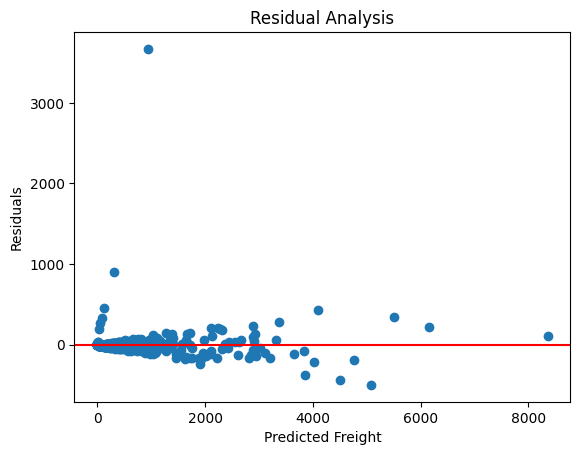

In [33]:
pred = model1.predict(X_test)

plt.scatter(pred, y_test - pred)
plt.axhline(0, color='red')
plt.xlabel("Predicted Freight")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()

## 🔍 Final Insights: Freight Cost Prediction

### 1. Business Problem Solved
Developed a predictive model to estimate freight costs for vendor invoices, enabling better cost planning, budgeting, and anomaly detection in logistics operations.

---

### 2. Key Drivers of Freight Cost
Exploratory analysis revealed:

- **Invoice Value (Dollars)** is the strongest predictor of freight cost  
- **Quantity** has a secondary influence, reflecting shipment volume  
- Derived features (e.g., unit cost, bulk indicator) contribute minimally  

This indicates a **value-based pricing structure**, where freight is largely proportional to invoice amount.

---

### 3. Model Performance & Selection
- Evaluated multiple models: Linear Regression, Decision Tree, and Random Forest  
- **Linear Regression achieved the best performance**:
  - R² ≈ 97%  
  - Lowest MAE and RMSE  

This confirms that the relationship between invoice value and freight cost is **highly linear**.

---

### 4. Feature Impact Analysis
A comparison between:
- **Simple Model (Dollars only)**  
- **Feature-Engineered Model (multiple features)**  

showed only **0.01% improvement in R²**, indicating:

- Invoice value alone captures nearly all variance  
- Additional features provide negligible incremental benefit  

---

### 5. Key Finding
Freight cost follows a **simple and predictable linear pattern**, primarily driven by invoice value, with minimal contribution from other variables.

---

### 6. Business Impact
- Enables **accurate freight cost estimation before shipment**  
- Helps in **budgeting and procurement planning**  
- Allows detection of **abnormal freight charges (anomaly detection use case)**  
- Reduces reliance on manual cost estimation  

---

### 7. Final Conclusion
The problem does not require complex models — a simple linear model is both **highly accurate and efficient**, making it ideal for deployment in real-world systems where speed and interpretability are critical.